<img width="800px" src="../fidle/img/header.svg"></img>

# <!-- TITLE --> [K3VAE2] - VAE, using a custom model class  (MNIST dataset)
<!-- DESC --> Construction and training of a VAE, using model subclass, with a latent space of small dimension.

<!-- AUTHOR : Jean-Luc Parouty (CNRS/SIMaP) -->

## Objectives :
 - Understanding and implementing a **variational autoencoder** neurals network (VAE)
 - Understanding a still more **advanced programming model**, using a **custom model**

The calculation needs being important, it is preferable to use a very simple dataset such as MNIST to start with.  
...MNIST with a small scale if you haven't a GPU ;-)

## What we're going to do :

 - Defining a VAE model
 - Build the model
 - Train it
 - Have a look on the train process

## Acknowledgements :
Thanks to **François Chollet** who is at the base of this example (and the creator of Keras !!).  
See : https://keras.io/examples/generative/vae


In [1]:
import os
from datetime import datetime

# --- Dataset directory (local, sans FIDLE)
datasets_dir = r"C:\Users\Kered\ML_DVRC_2025\Lecture10\data"

# --- Run info (équivalent minimal FIDLE)
run_id = "K3VAE2_" + datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = os.path.join(os.getcwd(), "runs", run_id)

# --- Create run folders
os.makedirs(run_dir, exist_ok=True)
os.makedirs(os.path.join(run_dir, "figures"), exist_ok=True)
os.makedirs(os.path.join(run_dir, "models"), exist_ok=True)

print("run_id      :", run_id)
print("run_dir     :", run_dir)
print("datasets_dir:", datasets_dir)

run_id      : K3VAE2_20260104_115120
run_dir     : c:\Users\Kered\ML_DVRC_2025\Lecture10\Lab\runs\K3VAE2_20260104_115120
datasets_dir: C:\Users\Kered\ML_DVRC_2025\Lecture10\data


## Step 1 - Init python stuff

In [3]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers

import numpy as np

from modules.models    import VAE
from modules.layers    import SamplingLayer
from modules.callbacks import ImagesCallback
from modules.datagen   import MNIST


import matplotlib.pyplot as plt
import scipy.stats
import sys

import fidle

# Init Fidle environment
# run_id, run_dir, datasets_dir = fidle.init('K3VAE2')

VAE.about()

<br>**FIDLE 2024 - VAE**

Version              : 2.0
Keras version        : 3.10.0


## Step 2 - Parameters
`scale` : with scale=1, we need 1'30s on a GPU V100 ...and >20' on a CPU !  
`latent_dim` : 2 dimensions is small, but usefull to draw !  
`fit_verbosity`: Verbosity of training progress bar: 0=silent, 1=progress bar, 2=One line  

`loss_weights` : Our **loss function** is the weighted sum of two loss:
 - `r_loss` which measures the loss during reconstruction.  
 - `kl_loss` which measures the dispersion.  

The weights are defined by: `loss_weights=[k1,k2]` where : `total_loss = k1*r_loss + k2*kl_loss`  
In practice, a value of \[1,.06\] gives good results here.


In [4]:
latent_dim    = 6
loss_weights  = [1,.06]

scale         = .2
seed          = 123

batch_size    = 64
epochs        = 4
fit_verbosity = 1

Override parameters (batch mode) - Just forget this cell

In [5]:
fidle.override('latent_dim', 'loss_weights', 'scale', 'seed', 'batch_size', 'epochs', 'fit_verbosity')

## Step 3 - Prepare data
`MNIST.get_data()` return : `x_train,y_train, x_test,y_test`,  \
but we only need x_train for our training.

Seeded (123)
Dataset loaded.
Concatenated.
Shuffled.
rescaled (0.2).
Normalized.
Reshaped.
splited (1).
x_train shape is  :  (14000, 28, 28, 1)
x_test  shape is  :  (0, 28, 28, 1)
y_train shape is  :  (14000,)
y_test  shape is  :  (0,)
Blake2b digest is :  7c19171fb716223bc92f


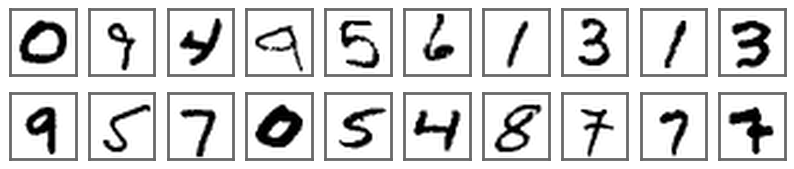

In [6]:
x_data, y_data, _,_ = MNIST.get_data(seed=seed, scale=scale, train_prop=1 )

fidle.scrawler.images(x_data[:20], None, indices='all', columns=10, x_size=1,y_size=1,y_padding=0, save_as='01-original')

## Step 4 - Build model
In this example, we will use a **custom model**.
For this, we will use :
 - `SamplingLayer`, which generates a vector z from the parameters z_mean and z_log_var - See : [SamplingLayer.py](./modules/layers/SamplingLayer.py)
 - `VAE`, a custom model with a specific train_step - See : [VAE.py](./modules/models/VAE.py)

#### Encoder

In [7]:
inputs    = keras.Input(shape=(28, 28, 1))
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(16, activation="relu")(x)

z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z         = SamplingLayer()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.compile()

#### Decoder

In [8]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs)
x       = layers.Reshape((7, 7, 64))(x)
x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(inputs, outputs, name="decoder")
decoder.compile()

#### VAE
`VAE` is a custom model with a specific train_step - See : [VAE.py](./modules/models/VAE.py)

In [9]:
vae = VAE(encoder, decoder, loss_weights)

vae.compile(optimizer='adam')

Fidle VAE is ready :-)  loss_weights=[1, 0.06]


## Step 5 - Train
### 5.1 - Using two nice custom callbacks :-)
Two custom callbacks are used:
 - `ImagesCallback` : qui va sauvegarder des images durant l'apprentissage - See [ImagesCallback.py](./modules/callbacks/ImagesCallback.py)
 - `BestModelCallback` : qui sauvegardera le meilleur model - See [BestModelCallback.py](./modules/callbacks/BestModelCallback.py)

In [10]:
callback_images      = ImagesCallback(x=x_data, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]

### 5.2 - Let's train !
With `scale=1`, need 1'15 on a GPU (V100 at IDRIS) ...or 20' on a CPU  

In [11]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(x_data, epochs=epochs, batch_size=batch_size, callbacks=callbacks_list, verbose=fit_verbosity)

chrono.show()

Epoch 1/4


c:\fidle-tp\fidle-env\lib\site-packages\keras\src\backend\common\backend_utils.py:91: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step/step - loss: 19024.427
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 139ms/step - loss: 19005.0098
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step/step - loss: 11816.65
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 139ms/step - loss: 11814.4238
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step/step - loss: 9984.77
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - loss: 9983.0352
Epoch 4/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step/step - loss: 8739.124
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - loss: 8738.7422
Duration :  133.25 seconds


## Step 6 - Training review
### 6.1 - History

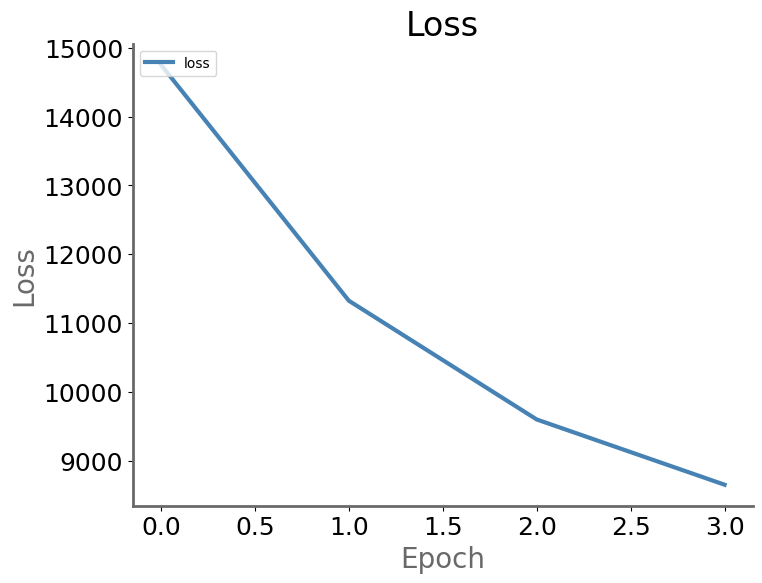

In [12]:
fidle.scrawler.history(history,  plot={"Loss":['loss']}, save_as='history')

### 6.2 - Reconstruction during training
At the end of each epoch, our callback saved some reconstructed images.  
Where :  
Original image -> encoder -> z -> decoder -> Reconstructed image

<br>**Original images :**

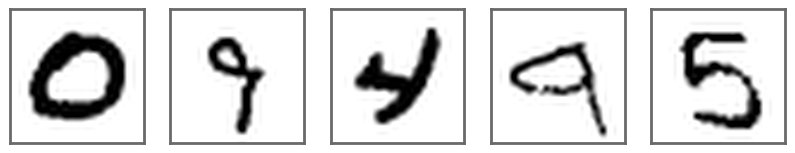

<br>**Encoded/decoded images**

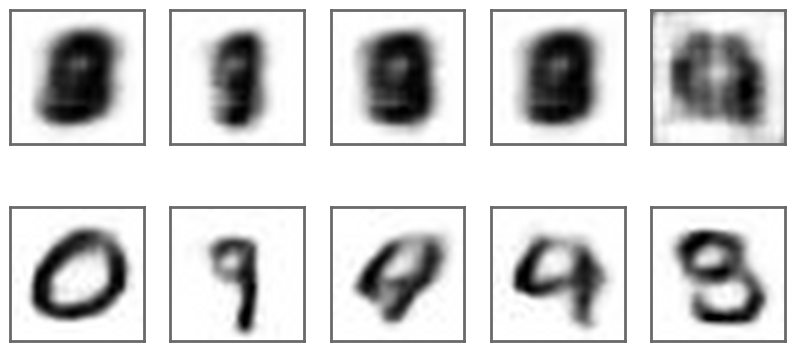

<br>**Original images :**

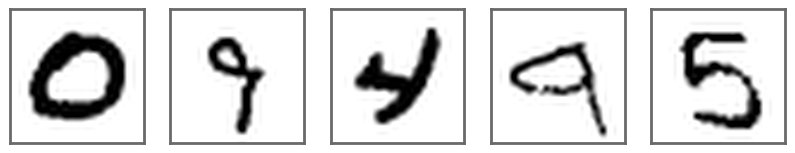

In [13]:
images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-original')

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-reconstruct')

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)


### 6.3 - Generation (latent -> decoder) during training

<br>**Generated images from latent space**

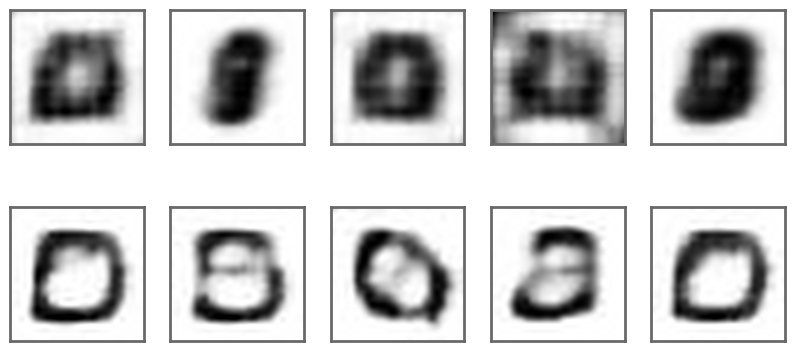

In [14]:
fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r, None, indices='all', columns=5, x_size=2,y_size=2, save_as='04-encoded')

### 6.4 - Save model

In [15]:
os.makedirs(f'{run_dir}/models', exist_ok=True)

vae.save(f'{run_dir}/models/vae_model.keras')

## Step 7 - Model evaluation

### 7.1 - Reload model

In [16]:
vae=VAE()
vae.reload(f'{run_dir}/models/vae_model.keras')

Fidle VAE is ready :-)  loss_weights=[1, 1]
Reloaded.


c:\fidle-tp\fidle-env\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\fidle-tp\fidle-env\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 7.2 - Image reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


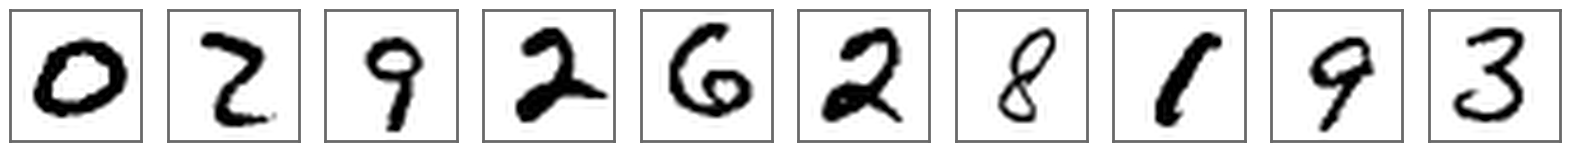

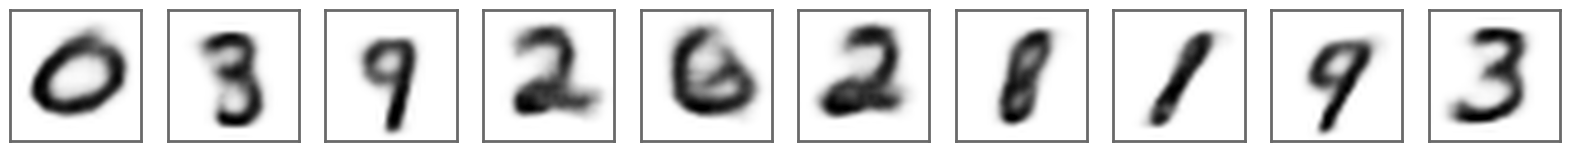

In [17]:
# ---- Select few images

x_show = fidle.utils.pick_dataset(x_data, n=10)

# ---- Get latent points and reconstructed images

z_mean, z_var, z  = vae.encoder.predict(x_show)
x_reconst         = vae.decoder.predict(z)

# ---- Show it

labels=[ str(np.round(z[i],1)) for i in range(10) ]
fidle.scrawler.images(x_show,    None, indices='all', columns=10, x_size=2,y_size=2, save_as='05-original')
fidle.scrawler.images(x_reconst, None, indices='all', columns=10, x_size=2,y_size=2, save_as='06-reconstruct')


### 7.3 - Visualization of the latent space

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


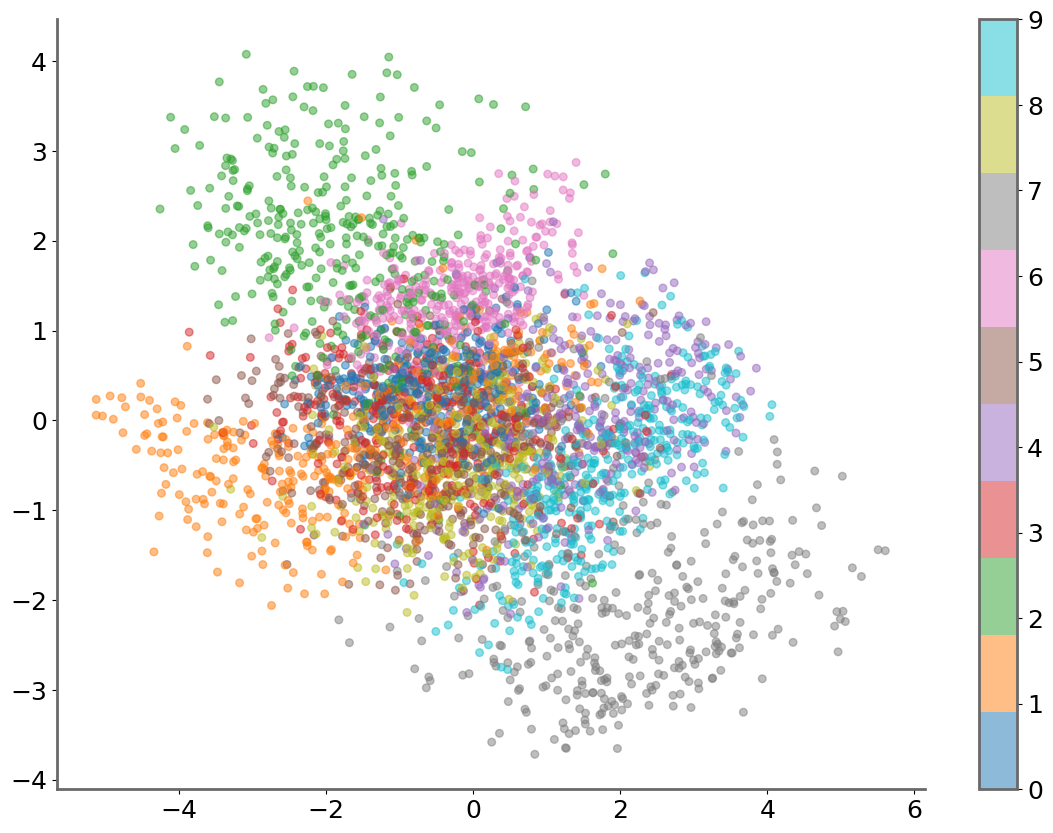

In [18]:
n_show = int(20000*scale)

# ---- Select images

x_show, y_show = fidle.utils.pick_dataset(x_data,y_data, n=n_show)

# ---- Get latent points

z_mean, z_var, z = vae.encoder.predict(x_show)

# ---- Show them

fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 0] , z[:, 1], c=y_show, cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
fidle.scrawler.save_fig('07-Latent-space')
plt.show()

### 7.4 - Generative latent space

In [19]:
if latent_dim>2:

    print('Sorry, This part can only work if the latent space is of dimension 2')

else:
    
    grid_size   = 18
    grid_scale  = 1

    # ---- Draw a ppf grid

    grid=[]
    for y in scipy.stats.norm.ppf(np.linspace(0.99, 0.01, grid_size),scale=grid_scale):
        for x in scipy.stats.norm.ppf(np.linspace(0.01, 0.99, grid_size),scale=grid_scale):
            grid.append( (x,y) )
    grid=np.array(grid)

    # ---- Draw latentspoints and grid

    fig = plt.figure(figsize=(10, 8))
    plt.scatter(z[:, 0] , z[:, 1], c=y_show, cmap= 'tab10', alpha=0.5, s=20)
    plt.scatter(grid[:, 0] , grid[:, 1], c = 'black', s=60, linewidth=2, marker='+', alpha=1)
    fidle.scrawler.save_fig('08-Latent-grid')
    plt.show()

    # ---- Plot grid corresponding images

    x_reconst = vae.decoder.predict([grid])
    fidle.scrawler.images(x_reconst, indices='all', columns=grid_size, x_size=0.5,y_size=0.5, y_padding=0,spines_alpha=0.1, save_as='09-Latent-morphing')



Sorry, This part can only work if the latent space is of dimension 2


In [ ]:
fidle.end()

---
<img width="80px" src="../fidle/img/logo-paysage.svg"></img>